In [15]:
# Implementation of Iso-P Triangular Elements
import numpy as np

def TrigGaussRuleInfo(rule, numer, point):
    """
    INPUT: rule (Gauss, can be 1, 3, -3, 6, 7), numer (not used here); point is index of sample point. 
    OUTPUT: two-level list [[zeta1, zeta2, zeta3], w], that is, triangular coords and integration weight.
    """

    p = rule

    i = point - 1 # python index

    if p == 1:
        info = [[1/3, 1/3, 1/3], 1]
    elif p == -3:    # midpoint rule
        zeta = [1/2, 1/2, 1/2]
        zeta[i] = 0
        info = [zeta, 1/3]
    elif p == 3:    
        zeta = [1/6, 1/6, 1/6]
        zeta[i] = 2/3
        info = [zeta, 1/3]


    elif p == 6:
        if i < 3: # python indexing means that instead of i <= 3, we evaluate i < 3 .
            g1 = (8 - np.sqrt(10) + np.sqrt(38 - 44 * np.sqrt(2/5))) / 18
            zeta = [g1, g1, g1]
            zeta[i] = 1 - 2 * g1
            info = [zeta, (620 + np.sqrt(213125 - 53320 * np.sqrt(10))) / 3720]

        else:
            g2 = (8 - np.sqrt(10) - np.sqrt(38 - 44 * np.sqrt(2/5))) / 18
            zeta = [g2, g2, g2]
            zeta[i - 3] = 1 - 2 * g2
            info = [zeta, (620 - np.sqrt(213125 - 53320 * np.sqrt(10))) / 3720]

    elif p == 7:
        if i == 0:
            info = [[1/3, 1/3, 1/3], 9/40]
        elif i < 4:
            zeta = [(6 - np.sqrt(15)) / 21] * 3 
            zeta[i - 1] = (9 + 2 * np.sqrt(15)) / 21
            info = [zeta, (155 - np.sqrt(15)) / 1200]
        else:
            zeta = [(6 + np.sqrt(15)) / 21] * 3
            zeta[i - 4] = (9 - 2 * np.sqrt(15)) / 21
            info = [zeta, (155 + np.sqrt(15)) / 1200]
    else:
        raise ValueError(f"Unsupported triangle Gauss rule: {rule}")
    
    return info



def Trig6IsoPShapeFunDer(ncoor, tcoor):
    """
    INPUT: ncoor (natural coords), list of [xi, yi] for 6 nodes, and tcoor (triangular coords [zeta1, zeta2, zeta3] of point to be computed
    OUTPUT: shape functions Nf, derivatives dN/dx and dN/dy and Jacobian det.
    """

    zeta1, zeta2, zeta3 = tcoor

    [x1, y1], [x2, y2], [x3, y3], [x4, y4], [x5, y5], [x6, y6] = ncoor

    dx4 = x4 - (x1 + x2) / 2
    dx5 = x5 - (x2 + x3) / 2
    dx6 = x6 - (x3 + x1) / 2

    dy4 = y4 - (y1 + y2) / 2
    dy5 = y5 - (y2 + y3) / 2
    dy6 = y6 - (y3 + y1) / 2

    # shape functions
    Nf = np.array([
        zeta1 * (2 * zeta1 - 1),
        zeta2 * (2 * zeta2 - 1),
        zeta3 * (2 * zeta3 - 1),
        4 * zeta1 * zeta2,
        4 * zeta2 * zeta3,
        4 * zeta3 * zeta1
    ])

    Jx21 = x2 - x1 + 4 * (dx4 * (zeta1 - zeta2) + (dx5 - dx6) * zeta3)

    Jx32 = x3 - x2 + 4 * (dx5 * (zeta2 - zeta3) + (dx6 - dx4) * zeta1)

    Jx13 = x1 - x3 + 4 * (dx6 * (zeta3 - zeta1) + (dx4 - dx5) * zeta2)

    Jy12 = y1 - y2 + 4 * (dy4 * (zeta2 - zeta1) + (dy6 - dy5) * zeta3)

    Jy23 = y2 - y3 + 4 * (dy5 * (zeta3 - zeta2) + (dy4 - dy6) * zeta1)

    Jy31 = y3 - y1 + 4 * (dy6 * (zeta1 - zeta3) + (dy5 - dy4) * zeta2)

    Jdet = Jx21 * Jy31 - Jy12 * Jx13

    # shape function derivatives with respect to x
    dNx = np.array([
        (4 * zeta1 - 1) * Jy23,
        (4 * zeta2 - 1) * Jy31,
        (4 * zeta3 - 1) * Jy12,
        4 * (zeta2 * Jy23 + zeta1 * Jy31),
        4 * (zeta3 * Jy31 + zeta2 * Jy12),
        4 * (zeta1 * Jy12 + zeta3 * Jy23)
    ]) / Jdet

    # shape function derivatives with respect to y
    dNy = np.array([
        (4 * zeta1 - 1) * Jx32,
        (4 * zeta2 - 1) * Jx13,
        (4 * zeta3 - 1) * Jx21,
        4 * (zeta2 * Jx32 + zeta1 * Jx13),
        4 * (zeta3 * Jx13 + zeta2 * Jx21),
        4 * (zeta1 * Jx21 + zeta3 * Jx32)
    ]) / Jdet

    return Nf, dNx, dNy, Jdet

def Trig6IsoPMembraneStiffness(ncoor, mprop, fprop, numer, rule = None):
    """
    INPUT: ncoor (node coords in 2D list), mprop as list [Emat, rho, alpha], 
           fprop (as one entry list [h], six entry list [h1, h2, h3, h4, h5, h6] or empty list.,
           numer (not used here), rule (specifies triangle Gauss rule, can be 1,-3,3,6,7)
    OUTPUT: Ke stiffness matrix
    """
  
    Emat = mprop[0]

    p = 3
    if rule is not None:
        p = rule

    th = 1.0

    if len(fprop) > 0:
        th = fprop[0]
        
    if rule not in (-3, 1, 3, 6, 7):
        raise ValueError("Illegal rule.")
    
    Ke = np.zeros((12, 12))
    
    for k in range(1, abs(p) + 1):
    
        tcoor, w = TrigGaussRuleInfo(p, numer, k)
    
        Nf, dNx, dNy, Jdet = Trig6IsoPShapeFunDer(ncoor, tcoor)
    
        if np.ndim(th) == 0:       # constant thickness
            h = th
        else:                      # interpolated thickness
            h = np.dot(th, Nf)
    
        c = w * Jdet * h / 2
    
        # Displacement-strain matrix
        B = np.zeros((3, 12))
        
        for i in range(6):
            B[0, 2*i]     = dNx[i]
            B[1, 2*i + 1] = dNy[i]
            B[2, 2*i]     = dNy[i]
            B[2, 2*i + 1] = dNx[i]
        
        Ke += c * (B.T @ Emat @ B)

    return Ke













    

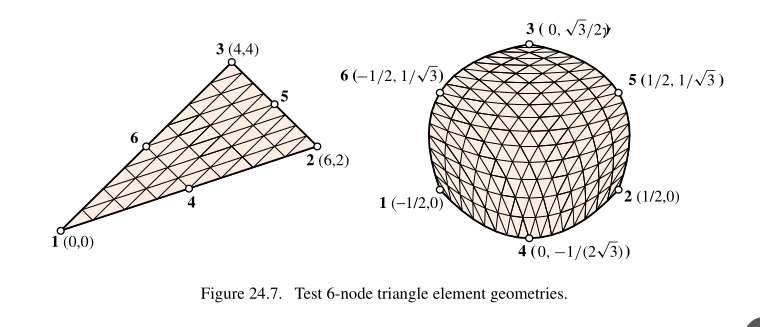


In [16]:
#Testing elements

# LEFT ELEMENT

h = 1
Em = 288
nu = 1/3

ncoor = np.array([
    [0, 0],    #corner node
    [6, 2],    #corner node
    [4, 4],    #corner node
    [3, 1],    #side node
    [5, 3],    #side node
    [2, 2]     #side node
], dtype=float)

Emat = Em/(1 - nu**2) * np.array([
    [1, nu, 0],
    [nu, 1, 0],
    [0, 0, (1 - nu)/2]
])

Ke = Trig6IsoPMembraneStiffness(ncoor,[Emat, 0, 0], [h], numer=False, rule=-3)

Ke_chop = np.where(np.abs(Ke) < 1e-10, 0.0, Ke)

print("Ke =")
print(Ke_chop)


eigvals = np.linalg.eigvalsh(Ke)
eigvals = np.where(np.abs(eigvals) < 1e-10, 0.0, eigvals)

print("eigs of Ke=")
print(eigvals)


Ke =
[[  54.   27.   18.    0.    0.    9.  -72.    0.    0.    0.    0.  -36.]
 [  27.   54.    0.  -18.    9.   36.    0.   72.    0.    0.  -36. -144.]
 [  18.    0.  216. -108.   54.  -36.  -72.    0. -216.  144.    0.    0.]
 [   0.  -18. -108.  216.  -36.   90.    0.   72.  144. -360.    0.    0.]
 [   0.    9.   54.  -36.  162.  -81.    0.    0. -216.  144.    0.  -36.]
 [   9.   36.  -36.   90.  -81.  378.    0.    0.  144. -360.  -36. -144.]
 [ -72.    0.  -72.    0.    0.    0.  576. -216.    0.  -72. -432.  288.]
 [   0.   72.    0.   72.    0.    0. -216.  864.  -72. -288.  288. -720.]
 [   0.    0. -216.  144. -216.  144.    0.  -72.  576. -216. -144.    0.]
 [   0.    0.  144. -360.  144. -360.  -72. -288. -216.  864.    0.  144.]
 [   0.  -36.    0.    0.    0.  -36. -432.  288. -144.    0.  576. -216.]
 [ -36. -144.    0.    0.  -36. -144.  288. -720.    0.  144. -216.  864.]]
eigs of Ke=
[   0.            0.            0.           12.89878564   57.54369927
  157.67594

In [17]:
#Testing elements

# RIGHT ELEMENT

h = 1
Em = 7*72
nu = 0

ncoor = np.array([
    [-1/2, 0],                  # corner node 
    [ 1/2, 0],                  # corner node 
    [ 0, np.sqrt(3)/2],         # corner node 
    [ 0, -1/(2*np.sqrt(3))],    # side node 
    [ 1/2, 1/np.sqrt(3)],       # side node
    [-1/2, 1/np.sqrt(3)]        # side node 
], dtype=float)

Emat = Em/(1 - nu**2) * np.array([
    [1, nu, 0],
    [nu, 1, 0],
    [0, 0, (1 - nu)/2]
])

for rule in [-3, 3, 6, 7]:

    Ke = Trig6IsoPMembraneStiffness(ncoor,[Emat, 0, 0],[h],numer=True,rule=rule)

    Ke_chop = np.where(np.abs(Ke) < 1e-10, 0.0, Ke)

    print("Ke=")
    print(Ke_chop)

    eigvals = np.linalg.eigvalsh(Ke)
    eigvals = np.where(np.abs(eigvals) < 1e-10, 0.0, eigvals)

    print("Eigenvalues of Ke=")
    print(eigvals)

Ke=
[[ 344.67811071   75.          -91.7986928    21.          -86.60254038
   -24.         -124.70765814  -72.          -20.78460969  -36.
   -20.78460969   36.        ]
 [  75.          258.07557033  -21.          -84.87048957   18.
   -90.06664199   96.            0.          -36.           20.78460969
  -132.         -103.92304845]
 [ -91.7986928   -21.          344.67811071  -75.          -86.60254038
    24.         -124.70765814   72.          -20.78460969  -36.
   -20.78460969   36.        ]
 [  21.          -84.87048957  -75.          258.07557033  -18.
   -90.06664199  -96.            0.          132.         -103.92304845
    36.           20.78460969]
 [ -86.60254038   18.          -86.60254038  -18.          214.77430014
     0.           41.56921938    0.          -41.56921938  144.
   -41.56921938 -144.        ]
 [ -24.          -90.06664199   24.          -90.06664199    0.
   387.9793809     0.          -41.56921938  -24.          -83.13843876
    24.          -83.1384